# 01 — Datautforskning: NO2 dagspot

Første steg i prosjektet *Magasinopsjon*. Vi gjør tre ting:

1. Laster inn ferdigprosessert daglig spotpris-data for prisområde NO2 (EUR/MWh, snitt over dagens MTUer)
2. Får visuelt og deskriptivt overblikk: tidsserie, fordeling, år-til-år-variasjon
3. Begynner å skille **signal** (sesong, langtidsnivå) fra **støy** (residual) — forarbeidet til Schwartz-kalibreringen i `02_price_model_calibration.ipynb`

Datakilden er ENTSO-E Transparency Platform. Innlasting og caching håndteres av `src.data_loader`; se den modulen for detaljer.


In [1]:
# Project root på sys.path slik at `from src.X import Y` fungerer fra notebooks/.
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data_loader import load_cached_daily
from src.plotting import set_style, PALETTE

# Konsistent plotstil for hele notebooken.
set_style()


## Last inn data

`load_cached_daily()` leser parquet-cachen som ble skrevet av `data_loader.refresh_cache()`. Hvis cachen mangler eller skal oppdateres, kjør fra prosjektroten:

```bash
uv run python -m src.data_loader
```


In [2]:
df = load_cached_daily()
# Konverter 'date' til ekte datetime og bruk den som index — gir bedre plotting og resampling.
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

print(f"Antall daglige observasjoner: {len(df):,}")
print(f"Tidsspenn: {df.index.min().date()} → {df.index.max().date()}")
print("\nFørste fem rader:")
df.head()


Antall daglige observasjoner: 2,339
Tidsspenn: 2020-01-01 → 2026-05-27

Første fem rader:


,price_eur_mwh,n_hours
date,,
2020-01-01,30.936250,24
2020-01-02,30.822500,24
2020-01-03,29.207500,24
2020-01-04,28.879583,24
2020-01-05,30.697083,24


## Deskriptiv statistikk

Vi ser særlig etter:

- Stor år-til-år-variasjon (kraftkrisen 2022)
- Eksistens av negative priser (forekommer ved overskudd av fornybar + lav etterspørsel)
- `n_hours`-kolonnen avslører overgangen fra time-MTU til 15-min-MTU midt i 2025 (24 → 96 observasjoner per dag)


In [3]:
# Hele perioden under ett.
overall = df['price_eur_mwh'].describe().round(2)
print("Hele perioden:")
print(overall.to_string())

# Per kalenderår med MTU-oppløsning som ekstra diagnose-kolonne.
by_year = df.groupby(df.index.year)['price_eur_mwh'].agg(
    snitt='mean', std='std', minimum='min', maks='max', dager='count'
).round(1)
by_year['mtu_per_dag'] = df.groupby(df.index.year)['n_hours'].mean().round(1)

by_year


Hele perioden:
count    2339.00
mean       82.95
std        81.03
min        -3.51
25%        37.59
50%        63.06
75%       103.42
max       660.06


,snitt,std,minimum,maks,dager,mtu_per_dag
date,,,,,,
2020,9.3,7.9,0.9,40.5,366,24.0
2021,75.1,44.2,17.9,387.4,365,24.0
2022,211.3,118.9,1.9,660.1,365,24.0
2023,79.5,31.9,-3.5,184.2,365,24.0
2024,50.1,27.2,6.9,348.4,366,24.0
2025,65.4,23.7,4.1,188.7,365,42.2
2026,101.1,18.0,43.0,151.7,147,96.0


## Tidsserie

Daglig snittpris over hele perioden. Den ekstreme toppen 2021–2023 er gass- og strømkrisen som fulgte invasjonen av Ukraina. Dette er en bemerkelsesverdig periode å ha med i datagrunnlaget, men det betyr også at en stasjonær prismodell estimert på hele 2020–2026 vil overdrive volatiliteten i en "normal" tilstand.


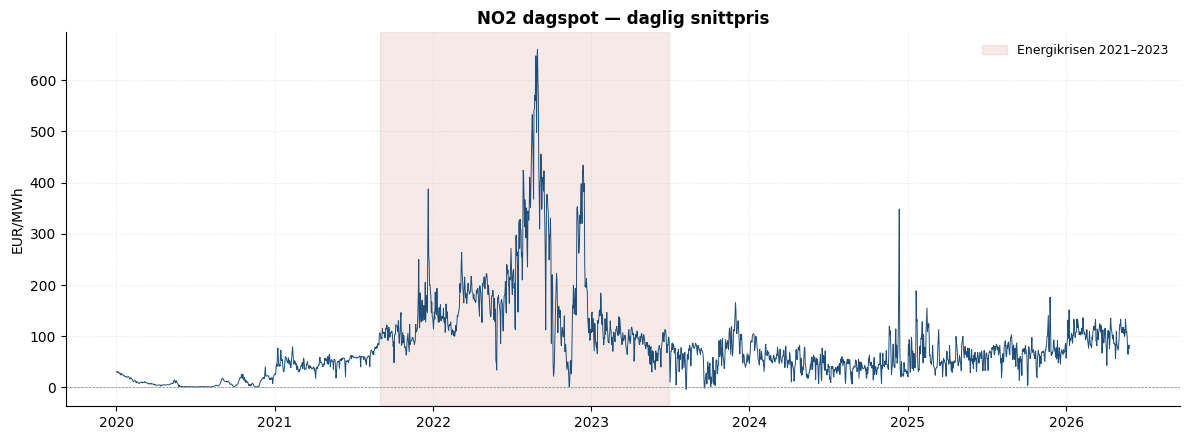

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(df.index, df['price_eur_mwh'], color=PALETTE['primary'], linewidth=0.7)

# Skraver krise-perioden for visuell kontekst.
crisis_start = pd.Timestamp('2021-09-01')
crisis_end = pd.Timestamp('2023-06-30')
ax.axvspan(crisis_start, crisis_end, alpha=0.10, color=PALETTE['highlight'],
           label='Energikrisen 2021–2023')

# 0-linje — synliggjør hvor (eller om) negative priser ligger.
ax.axhline(0, color=PALETTE['neutral'], linewidth=0.5, linestyle='--')

ax.set_title('NO2 dagspot — daglig snittpris')
ax.set_ylabel('EUR/MWh')
ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Sesongmønster

Norske kraftpriser har et tydelig sesongmønster: høyere om vinteren (lav magasinfylling, høyt forbruk) og lavere om sommeren (snøsmelting, lavere forbruk, lange dager). Vi visualiserer mønsteret ved å legge hver kalenderårs daglige profil oppå hverandre — i de mer normale årene 2024–2026 ser man rytmen tydelig.


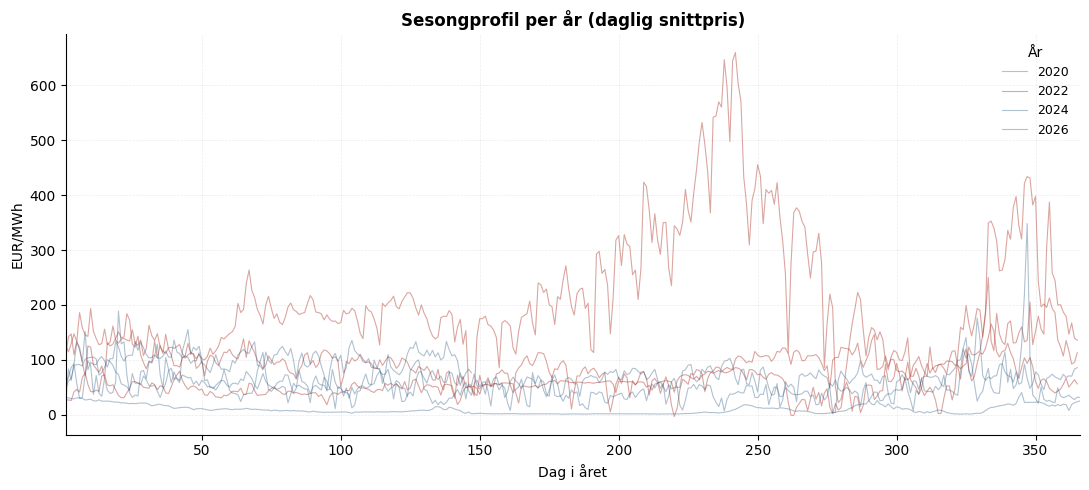

In [5]:
df['doy'] = df.index.dayofyear

fig, ax = plt.subplots(figsize=(11, 5))

# Krise-årene i rød tone, andre i blå tone — så det er lettere å lese sesongen i de normale årene.
years = sorted(df.index.year.unique())
labeled = set()
for year in years:
    sub = df[df.index.year == year]
    is_crisis = year in (2021, 2022, 2023)
    color = PALETTE['highlight'] if is_crisis else PALETTE['primary']
    alpha = 0.45 if is_crisis else 0.35
    label = str(year) if year in (2020, 2022, 2024, 2026) and year not in labeled else None
    if label:
        labeled.add(year)
    ax.plot(sub['doy'], sub['price_eur_mwh'],
            color=color, alpha=alpha, linewidth=0.8, label=label)

ax.set_title('Sesongprofil per år (daglig snittpris)')
ax.set_xlabel('Dag i året')
ax.set_ylabel('EUR/MWh')
ax.set_xlim(1, 366)
ax.legend(loc='upper right', title='År')
plt.tight_layout()
plt.show()


## Log-pris og enkel sesongdekomponering

Schwartz 1-faktor modellerer **log-prisen** som sum av:

$$\log P_t = f(t) + X_t, \qquad dX_t = -\kappa X_t\, dt + \sigma\, dW_t$$

der $f(t)$ er en deterministisk sesongkomponent (sinus/cosinus med ettårsperiode) og $X_t$ er en mean-reverting Ornstein–Uhlenbeck-residual.

Som forhåndsblikk fitter vi $f(t)$ med OLS her, slik at vi kan inspisere både fitten og hvor mye av variansen i log-pris som er sesong vs. residual.

> Negative priser (få) klippes til 1 EUR/MWh før logtransformasjon slik at OLS fungerer. Dette håndteres ordentlig i kalibreringen i neste notebook; her er det kun for visuell inspeksjon.


OLS-koeffisienter: intercept=3.924, sin=0.059, cos=0.247
R² (log-skala): 0.022  →  2.2% av varians i log-pris fanges av 1-års sesong


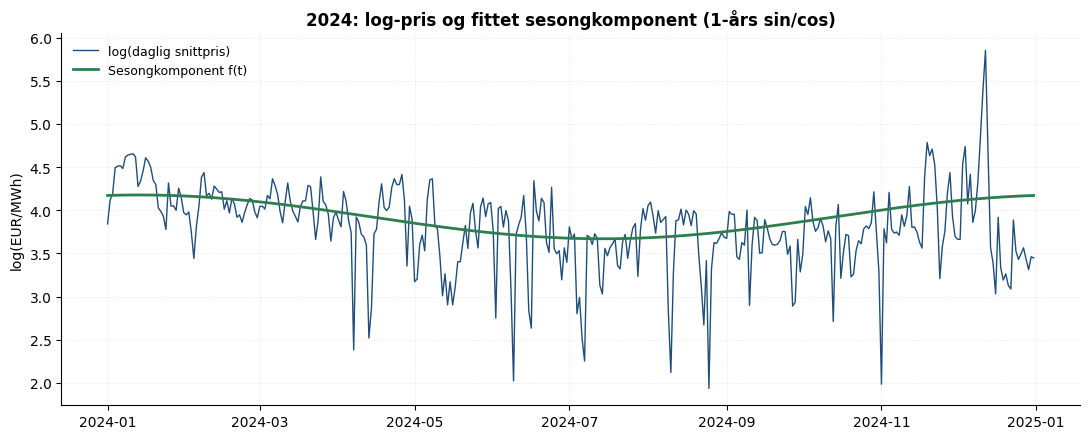

In [6]:
# Klipp bunnen ved 1 EUR/MWh for å håndtere negative og null-priser i denne visningen.
clip_floor = 1.0
log_p = np.log(df['price_eur_mwh'].clip(lower=clip_floor))

# Design-matrise: konstant + sin/cos med ettårsperiode (ω = 2π/365.25).
t = df.index.dayofyear.values
omega = 2 * np.pi / 365.25
X = np.column_stack([
    np.ones_like(t, dtype=float),
    np.sin(omega * t),
    np.cos(omega * t),
])

# OLS via numpy.linalg.lstsq.
beta, *_ = np.linalg.lstsq(X, log_p.values, rcond=None)
fitted = X @ beta
residual = log_p.values - fitted

r2 = 1 - residual.var() / log_p.values.var()
print(f"OLS-koeffisienter: intercept={beta[0]:.3f}, sin={beta[1]:.3f}, cos={beta[2]:.3f}")
print(f"R² (log-skala): {r2:.3f}  →  {r2*100:.1f}% av varians i log-pris fanges av 1-års sesong")

# Visualiser fit i 2024 (rolig år, gir tydeligst sesong).
fig, ax = plt.subplots(figsize=(11, 4.5))
mask = df.index.year == 2024
ax.plot(df.index[mask], log_p.values[mask],
        color=PALETTE['primary'], linewidth=1.0, label='log(daglig snittpris)')
ax.plot(df.index[mask], fitted[mask],
        color=PALETTE['season'], linewidth=2.0, label='Sesongkomponent f(t)')
ax.set_title('2024: log-pris og fittet sesongkomponent (1-års sin/cos)')
ax.set_ylabel('log(EUR/MWh)')
ax.legend()
plt.tight_layout()
plt.show()


## Residualstruktur

Det er **residualen** $X_t = \log P_t - f(t)$ som modelleres som mean-reverting i Schwartz-modellen. To ting vi sjekker visuelt:

1. **Fordeling** — er den rimelig normal? (Schwartz antar normal støy; tunge haler vil være et avvik vi bør være ærlige om.)
2. **Autokorrelasjon** — er det positiv lag-1-korrelasjon? Det er signaturen på mean-reversion (langsom decay i ACF), motsatt av hvit støy (lag-1 ≈ 0).


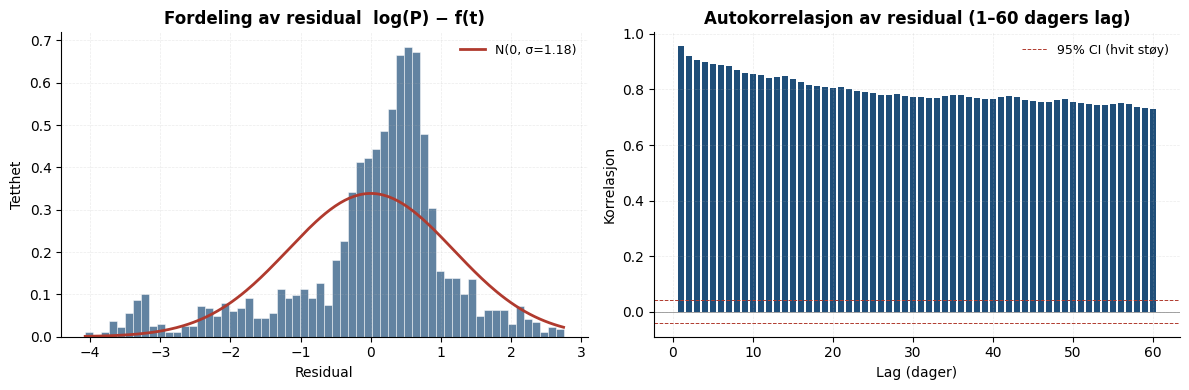

Lag-1 autokorrelasjon (≈ φ i AR(1)): 0.956
Implisert κ ≈ -ln(φ)/Δt med Δt=1 dag: 0.0451 per dag
Halveringstid (ln 2 / κ): 15.4 dager


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Venstre: histogram av residual med normalfordeling som referanse.
ax = axes[0]
ax.hist(residual, bins=60, density=True, color=PALETTE['primary'], alpha=0.7,
        edgecolor='white', linewidth=0.5)
xs = np.linspace(residual.min(), residual.max(), 200)
sigma = residual.std()
pdf = np.exp(-0.5 * (xs / sigma)**2) / (sigma * np.sqrt(2*np.pi))
ax.plot(xs, pdf, color=PALETTE['highlight'], linewidth=2, label=f'N(0, σ={sigma:.2f})')
ax.set_title('Fordeling av residual  log(P) − f(t)')
ax.set_xlabel('Residual')
ax.set_ylabel('Tetthet')
ax.legend()

# Høyre: autokorrelasjon opp til 60 dagers lag.
ax = axes[1]
max_lag = 60
acf = np.array([np.corrcoef(residual[:-k], residual[k:])[0, 1] for k in range(1, max_lag+1)])
ax.bar(range(1, max_lag+1), acf, color=PALETTE['primary'], width=0.8)
ax.axhline(0, color=PALETTE['neutral'], linewidth=0.5)
# 95% konfidensbånd for hvit støy under H0: ±1.96/sqrt(N).
ci = 1.96 / np.sqrt(len(residual))
ax.axhline(ci, color=PALETTE['highlight'], linewidth=0.7, linestyle='--', label='95% CI (hvit støy)')
ax.axhline(-ci, color=PALETTE['highlight'], linewidth=0.7, linestyle='--')
ax.set_title('Autokorrelasjon av residual (1–60 dagers lag)')
ax.set_xlabel('Lag (dager)')
ax.set_ylabel('Korrelasjon')
ax.legend()

plt.tight_layout()
plt.show()

# Forhåndsblikk på Schwartz-parametre — disse estimeres ordentlig i neste notebook.
phi = acf[0]
kappa_per_day = -np.log(phi)
halflife_days = np.log(2) / kappa_per_day
print(f"Lag-1 autokorrelasjon (≈ φ i AR(1)): {phi:.3f}")
print(f"Implisert κ ≈ -ln(φ)/Δt med Δt=1 dag: {kappa_per_day:.4f} per dag")
print(f"Halveringstid (ln 2 / κ): {halflife_days:.1f} dager")


## Oppsummering og overgang til steg 3

**Hva vi har sett:**

- **Tidsserie 2020–2026** med null hull i sekvensen, kombinert time- og 15-min-MTU-data aggregert til daglig snitt.
- **Sterk strukturell variasjon**: 2020 (~9 EUR/MWh) → 2022 (~211) → 2024 (~50). Kraftkrisen 2021–2023 dominerer.
- **Tydelig sesongmønster** i alle år, særlig synlig i de mer normale årene 2024–2026.
- **Sesongkomponenten** (1-faktor OLS) forklarer en betydelig andel av variansen i log-pris.
- **Residualen** har tydelig positiv autokorrelasjon (lag-1 ≫ 0) — signaturen på mean-reversion, som er Schwartz-modellens grunnforutsetning.

**Hva vi tar med oss inn i notebook 02 (kalibrering):**

1. Implementere `src.price_model` med fit-metode for $f(t)$ og AR(1)-estimat for $(\kappa, \sigma)$.
2. Vurdere om vi skal **ekskludere krise-årene 2021–2023** fra kalibreringen, eller beholde dem og diskutere konsekvensene for vannverdien. Begge er rimelige valg — det avhenger av hva vi ønsker modellen skal representere.
3. Validere modellen: simulere baner og sammenligne med faktisk data.

**Et eksplisitt forenklingsvalg:** vi modellerer **daglig snittpris**, ikke intra-dag-priser. Det er konsistent med at opsjonsmodellen i steg 4 gjør én go/no-go-beslutning per dag. Verdien av et vannmagasin på dette tidsperspektivet er dominert av dag-til-dag-variasjon, ikke time-til-time.
